#**VonHeijne algorithm evaluation**

## Execution

#### Importing libraries and datasets





In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_curve
import math

In [81]:
positive = pd.read_csv("/content/positive_set.tsv", sep="\t")
negative = pd.read_csv("/content/negative_set.tsv", sep="\t")

positive["type"] = "Positive"
negative["type"] = "Negative"

print(positive["protein_id"].is_unique) #Checking if protein_id can be used as label
print(negative["protein_id"].is_unique)

positive = positive.set_index("protein_id")
negative = negative.set_index("protein_id")
positive = positive.rename(columns={"class": "dataset_class"})
negative = negative.rename(columns={"class": "dataset_class"})

tot = pd.concat([positive, negative])
new_tot = tot.copy()
new_tot = new_tot[["dataset_class",'cv_subset','type','kingdom','organism_name',"TM_helix_presence","pos_cleavage_site"]]

new_tot["sequence"] = pd.Series("", index=new_tot.index)
new_tot["motif"] = pd.Series("", index=new_tot.index)

new_tot.head()

True
True


,dataset_class,cv_subset,type,kingdom,organism_name,TM_helix_presence,pos_cleavage_site,sequence,motif
protein_id,,,,,,,,,
Q99MA2,Training,1,Positive,Metazoa,Rattus norvegicus,NaN,22.0,,
P17948,Training,1,Positive,Metazoa,Homo sapiens,NaN,26.0,,
P41271,Training,1,Positive,Metazoa,Homo sapiens,NaN,16.0,,
Q8I948,Training,1,Positive,Metazoa,Acanthoscurria gomesiana,NaN,23.0,,
Q92154,Training,1,Positive,Metazoa,Coturnix japonica,NaN,17.0,,


#### Add sequence & motif to the dataframe

In [82]:
positive_seq_fasta = "/content/cluster-results_positive_rep_seq.fasta"
negative_seq_fasta = "/content/cluster-results_negative_rep_seq.fasta"
training_motif = "/content/training_motif_alignment.fasta"
test_motif = "/content/test_motif_alignment.fasta"

with open(positive_seq_fasta,"r") as file:
  header = True
  for line in file:
    if header == True:
      ID = str(line.split()[0][1:])
      header = False
      continue
    if header == False:
      if ID in new_tot.index: # Check if ID exists in the dataframe index
        new_tot.loc[ID, "sequence"] = line.strip()
      header = True
file.close()

with open(negative_seq_fasta,"r") as file:
  header = True
  for line in file:
    if header == True:
      ID = str(line.split()[0][1:])
      header = False
      continue
    if header == False:
      if ID in new_tot.index: # Check if ID exists in the dataframe index
        new_tot.loc[ID, "sequence"] = line.strip()
      header = True
file.close()

with open(training_motif,"r") as file:
  header = True
  for line in file:
    if header == True:
      ID = str(line.split()[0][1:])
      header = False
      continue
    if header == False:
      if ID in new_tot.index: # Check if ID exists in the dataframe index
        new_tot.loc[ID, "motif"] = line.strip()
      header = True
file.close()

with open(test_motif,"r") as file:
  header = True
  for line in file:
    if header == True:
      ID = str(line.split()[0][1:])
      header = False
      continue
    if header == False:
      if ID in new_tot.index: # Check if ID exists in the dataframe index
        new_tot.loc[ID, "motif"] = line.strip()
      header = True
file.close()

original_training = new_tot.copy()
benchmark = new_tot.copy()
original_training = original_training.query('dataset_class == "Training"')
benchmark = benchmark.query('dataset_class == "Test"')


#### Identify the splits between training, validation and testing data

In [4]:
def df_subset(df):
  for id,row in df.iterrows():
    if row["cv_subset"] == 1:
      df.loc[id, "dataset_class"] = "Validation"
    else:
      df.loc[id, "dataset_class"] = "Training"
  return


#### Matrix generation

In [5]:
def matrix_generation(df):
  df = df.query('type == "Positive"')
  df_row_count = df.shape[0] # N number of rows
  shape_motif = (-13,2) #motif indexes
  #Matrix init with pseudocount
  matrix = {shape_motif[0]:{"A": 1, "Q": 1, "L": 1, "S": 1, "R": 1, "E": 1, "K": 1, "T": 1, "N": 1, "G": 1, "M": 1, "W": 1, "D": 1, "H": 1, "F": 1, "Y": 1, "C": 1, "I": 1, "P": 1, "V": 1}}
  for i in range(shape_motif[0]+1, shape_motif[1]):
    matrix[i] = {"A": 1, "Q": 1, "L": 1, "S": 1, "R": 1, "E": 1, "K": 1, "T": 1, "N": 1, "G": 1, "M": 1, "W": 1, "D": 1, "H": 1, "F": 1, "Y": 1, "C": 1, "I": 1, "P": 1, "V": 1}

  #Counting aa occurences
  for _, row in df.iterrows():
    motif = str(row["motif"])
    for index,aa in enumerate(motif):
      if aa == "X" or aa == "n" or aa == "a" or aa == "U":
        continue
      matrix[index-13][aa] += 1

  #Dividing for N + 20
  for key, value in matrix.items():
    for index, aa in matrix[key].items():
      matrix[key][index] = (aa/(df_row_count+20))

  #Transformation into a pd df
  matrix_df = pd.DataFrame.from_dict(matrix, orient='index')
  reference = {"A": 0.0825, "Q": 0.0393, "L": 0.0964, "S": 0.0665, "R": 0.0552, "E": 0.0671, "K": 0.0579, "T": 0.0536, "N": 0.0406, "G": 0.0707, "M": 0.0241, "W": 0.0110, "D": 0.0546, "H": 0.0227, "F": 0.0386, "Y": 0.0292, "C": 0.0138, "I": 0.0590, "P": 0.0474, "V": 0.0685}

  #Dividing for reference
  for _,row in matrix_df.iterrows():
    for aa, value in reference.items():
      row[aa] = row[aa]/value

  #Apply log
  matrix_df = matrix_df.apply(np.log)
  return matrix_df


#### Score prediction of an entry using the matrix

In [6]:
def score_prediction(matrix, entry):
  score = 0
  best_score = -100000000000000000000000000000000000000
  seq = entry["sequence"]
  l = 15
  for index in range(91):
    motif = seq[index:index+l]
    position = -13
    for residue in motif:
      if residue == "X" or residue == "n" or residue == "a" or residue == "U":
        continue
      score += matrix.loc[position][residue]
      position+=1
    if score > best_score:
      best_score = score
  return best_score

#### Threshold estimation

In [7]:
def threshold_estimation(df):
  y_validation = []
  entry_types = df["type"]
  for entry in entry_types:
    if entry == "Positive":
      y_validation.append(1)
    else:
      y_validation.append(0)
  y_validation_scores = []
  for id,row in df.iterrows():
     entry_score = score_prediction(w, row)
     y_validation_scores.append(entry_score)
  precision, recall, thresholds = precision_recall_curve(y_validation, y_validation_scores)
  fscore = (2 * precision * recall) / (precision + recall)
  index = np.argmax(fscore)
  optimal_threshold = thresholds[index]
  return optimal_threshold

#### Classification of an entry based on its score

In [8]:
def classification(score, threshold):
  if score >= threshold:
    entry_class = "Positive"
  else:
    entry_class = "Negative"
  return entry_class

#### Computing performance metrics

In [28]:
def performance_metrics(df):
  TP = FN = FP = TN = 1
  fn_list = fp_list = []
  for id,row in df.iterrows():
    real = row["type"]
    predicted = row["predicted"]
    if real == "Positive" and predicted == "Positive":
      TP += 1
      df.loc[id, "classified"] = "TP"
    elif real == "Positive" and predicted == "Negative":
      FN += 1
      fn_list.append(id)
      df.loc[id, "classified"] = "FN"
    elif real == "Negative" and predicted == "Positive":
      FP += 1
      fp_list.append(id)
      df.loc[id, "classified"] = "FP"
    elif real == "Negative" and predicted == "Negative":
      TN += 1
      df.loc[id, "classified"] = "TN"
  precision = TP / (TP + FP)
  recall = TP / (TP + FN)
  f1_score = 2*precision*recall / (precision + recall)
  accuracy = (TP + TN) / (TP + TN + FP + FN)
  mcc = (((TP * TN) - (FP * FN))/math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)))
  print("TP:", TP," FP:",FP," TN:",TN," FN:",FN)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1 score:", f1_score)
  print("Accuracy:", accuracy)
  print("MCC:",mcc)
  return [TP,TN,FP,FN,fn_list,fp_list,precision,recall,f1_score,accuracy,mcc]

#### Final execution

In [30]:
metrics_tot = []
threshold_tot = []

df_subset(original_training)
training = original_training.copy()
training = training.query('dataset_class == "Training"')
w = matrix_generation(training)
print("Matrix generated")
print(w)

print("Validation")
validation = original_training.copy()
validation = validation.query('dataset_class == "Validation"')
validation["predicted"] = pd.Series("", index=new_tot.index)
threshold = threshold_estimation(validation)
print("Threshold: ",threshold)
for id,row in validation.iterrows():
    entry_score = score_prediction(w, row)
    validation.loc[id, "predicted"] = classification(entry_score, threshold)

print("Testing")
benchmark["predicted"] = pd.Series("", index=new_tot.index)
for id,row in benchmark.iterrows():
    entry_score = score_prediction(w, row)
    benchmark.loc[id, "predicted"] = classification(entry_score, threshold)

print("Finished")



Matrix generated
            A         Q         L         S         R         E         K  \
-13  0.285154 -2.244108  1.398353 -0.205136 -1.890699 -2.268242 -2.631601   
-12  0.285154 -3.342720  1.480310 -0.690644 -3.682459 -3.877680 -2.631601   
-11  0.192372 -1.396810  1.408972 -0.313350 -2.989312 -3.184533 -3.730213   
-10  0.149812 -1.733283  1.391210 -0.062035 -2.073021 -3.184533 -3.037066   
-9   0.790903 -1.396810  1.343494 -0.062035 -2.583847 -2.268242 -3.730213   
-8   0.677880 -0.857814  1.073204  0.290185 -2.583847 -2.085921 -3.037066   
-7   0.297732 -0.703663  1.265329 -0.018550 -1.485234 -1.680455 -1.784303   
-6   0.669296 -1.956426  0.770633 -0.040056 -1.890699 -2.491386 -2.631601   
-5   0.694829  0.346159 -0.348182  0.608639 -0.792087 -0.742186 -1.427628   
-4   0.219771 -0.084624  0.413958  0.475108 -0.546965 -0.658804 -1.022163   
-3   1.178396 -3.342720 -0.907798  0.674597 -2.296165 -2.491386 -2.343919   
-2   0.074589  0.846934  0.355118  0.513329  0.101731  0.14

In [31]:
benchmark["classified"] = pd.Series("", index=new_tot.index)
print("Performance metrics on benchmark: ")
metrics = performance_metrics(benchmark)

Performance metrics on benchmark: 
TP: 141  FP: 41  TN: 1748  FN: 79
Precision: 0.7747252747252747
Recall: 0.6409090909090909
F1 score: 0.7014925373134328
Accuracy: 0.9402687904430065
MCC: 0.6723476262325688


## Evaluation of results

#### Importing libraries for plots

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)

#### TP TN FP FN dataframes

In [65]:
tp = benchmark.query('classified == "TP"')
tn = benchmark.query('classified == "TN"')
fp = benchmark.query('classified == "FP"')
fn = benchmark.query('classified == "FN"')
fn.head()

,dataset_class,cv_subset,type,kingdom,organism_name,TM_helix_presence,pos_cleavage_site,sequence,motif,predicted,classified
protein_id,,,,,,,,,,,
P79263,Test,0,Positive,Metazoa,Sus scrofa,NaN,27.0,MKTLSPTGYGLLLVLPLLLAVLQSTTAHKNDINIYSLTVDSKVSSR...,LPLLLAVLQSTTAHK,Negative,FN
P21814,Test,0,Positive,Metazoa,Ovis aries,NaN,25.0,MSHRRMQLALSLVFILCGLFNSIFCEKQQHSQQHANLVLLKKISAF...,VFILCGLFNSIFCEK,Negative,FN
P19320,Test,0,Positive,Metazoa,Homo sapiens,NaN,24.0,MPGKMVVILGASNILWIMFAASQAFKIETTPESRYLAQIGDSVSLT...,SNILWIMFAASQAFK,Negative,FN
P58912,Test,0,Positive,Metazoa,Phyllodiscus semoni,NaN,21.0,MSKPIIFLLTAFVVLTDLGATEDTEKVEVKAKPSKTSRGAIGQGFE...,LTAFVVLTDLGATED,Negative,FN
Q62813,Test,0,Positive,Metazoa,Rattus norvegicus,NaN,28.0,MVGRVQPDRKQLPLVLLRLLCLLPTGLPVRSVDFNRGTDNITVRQG...,LLRLLCLLPTGLPVR,Negative,FN


#### FP and FN distribution among kindom

In [34]:
# import data
fp_kingdom = fp['kingdom'].value_counts()
fn_kingdom = fn['kingdom'].value_counts()
fp_species = fp['organism_name'].value_counts()
fn_species = fn['organism_name'].value_counts()
k_colors = sns.color_palette("pastel", len(fn_kingdom))
s_colors = sns.color_palette("pastel", len(fn_species))

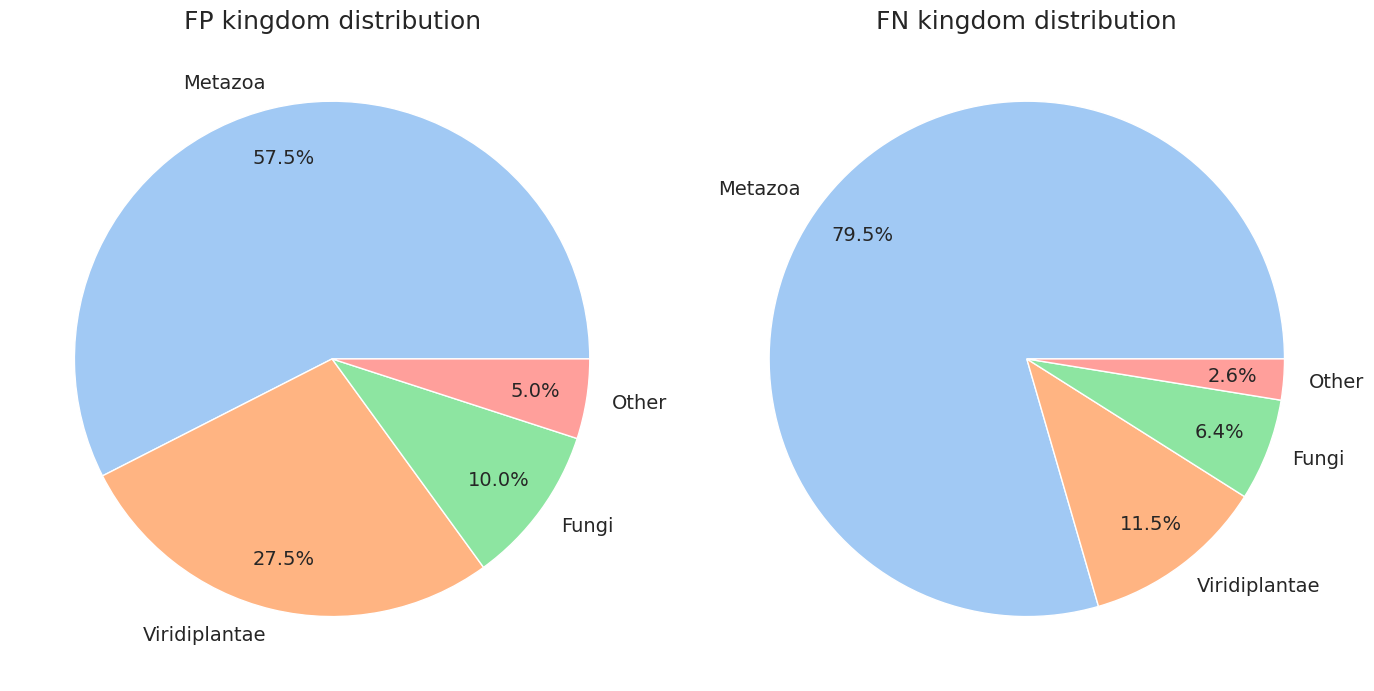

In [84]:
# filter kingdom data
def filter_kingdom(kingdom):
  kingdom_top = kingdom.head(3)
  k_other_sum = kingdom.iloc[3:].sum()
  k_other_series = pd.Series({"Other": k_other_sum})
  kingdom_grouped = pd.concat([kingdom_top, k_other_series])
  return kingdom_grouped
fp_k_grouped = filter_kingdom(fp_kingdom)
fn_k_grouped = filter_kingdom(fn_kingdom)

# kingdom piecharts
kingdom_fig, (kingdom_ax1, kingdom_ax2) = plt.subplots(1,2, figsize=(14, 7))
kingdom_ax1.pie(
    fp_k_grouped.values,
    labels=fp_k_grouped.index,
    autopct='%1.1f%%',
    colors=k_colors,
    textprops={'fontsize': 14},
    pctdistance=0.8,
)
kingdom_ax1.set_title("FP kingdom distribution", fontsize=18)

kingdom_ax2.pie(
    fn_k_grouped.values,
    labels=fn_k_grouped.index,
    autopct='%1.1f%%',
    colors=k_colors,
    textprops={'fontsize': 14},
    pctdistance=0.8,
)
kingdom_ax2.set_title("FN kingdom distribution", fontsize=18)

kingdom_fig.tight_layout()
kingdom_fig.savefig("fp_fn_kingdom_piechart.png")


#### FP and FN distribution among species

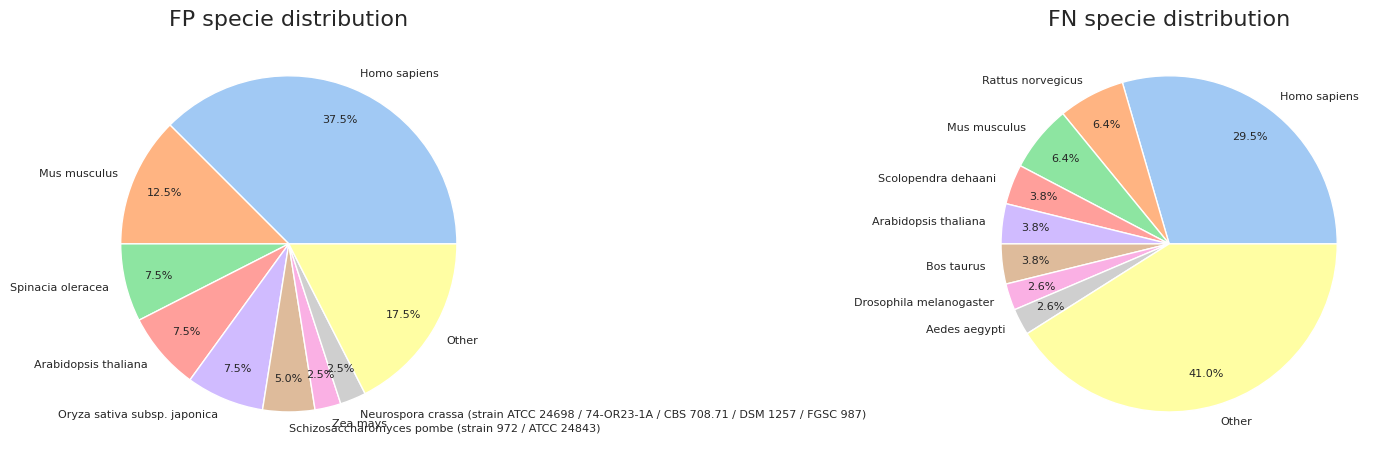

In [90]:
# filter species data
def filter_species(species):
  species_top = species.head(8)
  s_other_sum = species.iloc[8:].sum()
  s_other_series = pd.Series({"Other": s_other_sum})
  species_grouped = pd.concat([species_top, s_other_series])
  return species_grouped
fp_s_grouped = filter_species(fp_species)
fn_s_grouped = filter_species(fn_species)

# species piecharts
specie_fig, (specie_ax1, specie_ax2) = plt.subplots(1,2, figsize=(14, 7))
specie_ax1.pie(
    fp_s_grouped.values,
    labels=fp_s_grouped.index,
    autopct='%1.1f%%',
    colors=s_colors,
    textprops={'fontsize': 8},
    pctdistance=0.8
)
specie_ax1.set_title("FP specie distribution", fontsize=16)

specie_ax2.pie(
    fn_s_grouped.values,
    labels=fn_s_grouped.index,
    autopct='%1.1f%%',
    colors=s_colors,
    textprops={'fontsize': 8},
    pctdistance=0.8,
)
specie_ax2.set_title("FN specie distribution", fontsize=16)

specie_fig.tight_layout()
specie_fig.savefig("fp_fn_species_piechart.png")


#### FP and FN distribution on TM-helices

In [69]:
#FPR = FP / (TN + FP)
#  return [TP,TN,FP,FN,fn_list,fp_list,precision,recall,f1_score,accuracy,mcc]
print("General false positive rate (FPR)")
FN = metrics[3]-1
FP = metrics[2]-1
TN = metrics[1]-1
TP = metrics[0]-1
FPR = (FP / (TN + FP))*100
print(FPR)
print()

#FPRtm = FPtm / (Ntm)
print("Transmembrane false positive rate")
fp_tm_count = fp['TM_helix_presence'].value_counts()
FP_tm = fp_tm_count.get(True, 0)
tn_tm_count = tn['TM_helix_presence'].value_counts()
TN_tm = tn_tm_count.get(True, 0)
FPRtm = (FP_tm / (TN_tm + FP_tm))*100
print(FPRtm)

General false positive rate (FPR)
2.238388360380526

Transmembrane false positive rate
2.214022140221402


#### FN relation to different composition of the cleavage-site
##### Extract the cleavage-site motifs [-13,+2] of False Negatives and use WebLogo to produce the sequence logo

In [83]:
output = "test_fn_motif_alignment.fasta"
with open(output,"w") as file:
  for id,row in fn.iterrows():
    file.write(f">{id}\n")
    file.write(f"{row['motif']}\n")
file.close()
